# CBED Frame Simulation

Demonstrate how to simulate a CBED frame using this package, with pseudo-realistic and controllable quality.

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from cbed_simulation.crystal_orientation import OrientedPhase, ExperimentInformation

We load a structure in a given orientation, this can be an `hkl` index or an `orix.quaternion.Rotation` object for an aribtrary Euler angle.

In [2]:
phase = OrientedPhase.from_cif("./tests/Si.cif")

The `ExperimentInformation` sets the physical parameters of the simulation, notably the detector shape and the scale factor.

In [16]:
experiment = ExperimentInformation(
    frame_shape=(512, 512),
    radius_px=12,
    transmitted_centre_px=complex(256, 256),
    pattern_scale_factor=120.,  # pixels / Å-1
)

In [17]:
sim_peaks = phase.peak_positions(experiment)
sim_peaks.modify_000_intensity(0.5)
sim_peaks.modify_intensities(0.25)
sim_frame = phase.synthetic(experiment, sim_peaks)

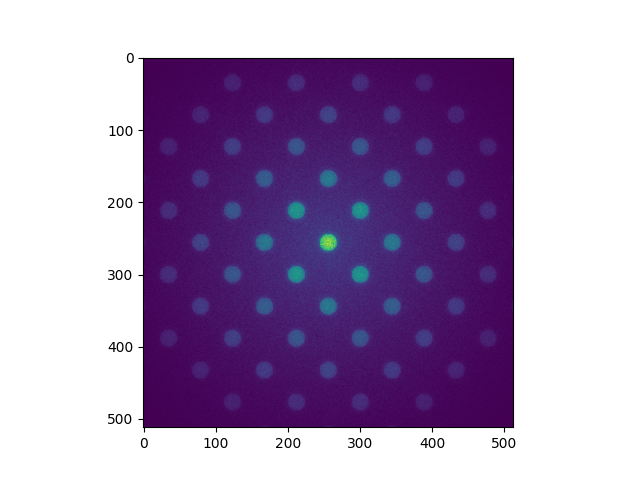

In [18]:
plt.figure()
plt.imshow(sim_frame)